### Prophet + XGBoost 시계열 예측


### 1. 환경 설정


In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import os
import sys
import subprocess
import warnings
import datetime
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

warnings.filterwarnings('ignore')

# 한글 폰트 설정
!apt-get -qq install fonts-nanum > /dev/null 2>&1
mpl.font_manager.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
mpl.rcParams['font.family'] = 'NanumGothic'
mpl.rcParams['axes.unicode_minus'] = False

base_path = '/content/drive/MyDrive/26-1_BITAmin_TS_project'
PROCESSED_DIR = os.path.join(base_path, 'processed_data')
os.makedirs(PROCESSED_DIR, exist_ok=True)

print('base_path:', base_path)
print('processed_dir:', PROCESSED_DIR)


Mounted at /content/drive
base_path: /content/drive/MyDrive/26-1_BITAmin_TS_project
processed_dir: /content/drive/MyDrive/26-1_BITAmin_TS_project/processed_data


### 2. 라이브러리 설치


In [2]:
def ensure_package(pkg_name):
    try:
        __import__(pkg_name)
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg_name])

for pkg in ['prophet', 'xgboost', 'scikit-learn', 'pyarrow']:
    ensure_package(pkg)

from prophet import Prophet
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

print('패키지 설치 완료')


패키지 설치 완료


### 3) 데이터 로드


In [3]:
def pick_existing(paths):
    for p in paths:
        if os.path.exists(p):
            return p
    return None

daily_path = pick_existing([
    os.path.join(PROCESSED_DIR, 'station_hotspot_daily.parquet'),
])
meta_path = pick_existing([
    os.path.join(PROCESSED_DIR, 'clustered_hotspot.parquet'),
    os.path.join(PROCESSED_DIR, 'station_hotspot_map.parquet'),
])

assert daily_path is not None, 'station_hotspot_daily.parquet 파일이 없습니다.'
assert meta_path is not None, 'clustered_hotspot.parquet 또는 station_hotspot_map 파일이 없습니다.'

daily_raw = pd.read_parquet(daily_path)
meta_raw = pd.read_parquet(meta_path)

print('daily path:', daily_path)
print('meta path :', meta_path)
print('daily shape:', daily_raw.shape)
print('meta shape :', meta_raw.shape)
display(daily_raw.head())
display(meta_raw.head())


daily path: /content/drive/MyDrive/26-1_BITAmin_TS_project/processed_data/station_hotspot_daily.parquet
meta path : /content/drive/MyDrive/26-1_BITAmin_TS_project/processed_data/clustered_hotspot.parquet
daily shape: (568667, 3)
meta shape : (2790, 9)


,date,추정고장대여소ID,고장건수
0,2021-02-02,00133,3
1,2021-02-02,00117,2
2,2021-02-02,00212,2
3,2021-02-02,00339,2
4,2021-02-02,00614,2


,추정고장대여소ID,위도,경도,고장건수,log_고장건수,dbscan_cluster,kmeans_cluster,ui_cluster,핫스팟등급
0,00102,37.555649,126.910629,754,6.626718,0,3,3,HIGH
1,00103,37.554951,126.910835,623,6.436150,0,3,3,HIGH
2,00104,37.550629,126.914986,274,5.616771,0,3,3,LOW
3,00105,37.550007,126.914825,125,4.836282,0,3,3,LOW
4,00106,37.548645,126.912826,458,6.129050,0,3,3,MID


### 4. 데이터 전처리


In [5]:
def normalize_station_id(s: pd.Series) -> pd.Series:
    return (
        s.astype('string').str.strip()
        .str.replace(r'\.0$', '', regex=True)
        .str.replace(r'[^0-9]', '', regex=True)
        .replace({'': pd.NA})
        .str.zfill(5)
    )

# daily 정리
x = daily_raw.copy()
x.columns = [str(c).strip() for c in x.columns]

if 'date' not in x.columns:
    if '일자' in x.columns:
        x['date'] = x['일자']
    else:
        raise ValueError('daily 데이터에 date(또는 일자) 컬럼이 없습니다.')

if '추정고장대여소ID' not in x.columns:
    raise ValueError('daily 데이터에 추정고장대여소ID 컬럼이 없습니다.')
if '고장건수' not in x.columns:
    raise ValueError('daily 데이터에 고장건수 컬럼이 없습니다.')

x['date'] = pd.to_datetime(x['date'], errors='coerce')
x['추정고장대여소ID'] = normalize_station_id(x['추정고장대여소ID'])
x['고장건수'] = pd.to_numeric(x['고장건수'], errors='coerce')

daily = x.dropna(subset=['date', '추정고장대여소ID', '고장건수']).copy()
daily = daily[daily['고장건수'] >= 0].copy()

# station 메타 정리
m = meta_raw.copy()
m.columns = [str(c).strip() for c in m.columns]

assert '추정고장대여소ID' in m.columns, 'meta 데이터에 추정고장대여소ID가 없습니다.'
assert '위도' in m.columns and '경도' in m.columns, 'meta 데이터에 위도/경도가 없습니다.'

m['추정고장대여소ID'] = normalize_station_id(m['추정고장대여소ID'])
m['위도'] = pd.to_numeric(m['위도'], errors='coerce')
m['경도'] = pd.to_numeric(m['경도'], errors='coerce')

if '핫스팟등급' not in m.columns and '고장건수' in m.columns:
    q90 = pd.to_numeric(m['고장건수'], errors='coerce').quantile(0.90)
    q70 = pd.to_numeric(m['고장건수'], errors='coerce').quantile(0.70)
    m['핫스팟등급'] = 'LOW'
    m.loc[pd.to_numeric(m['고장건수'], errors='coerce') >= q70, '핫스팟등급'] = 'MID'
    m.loc[pd.to_numeric(m['고장건수'], errors='coerce') >= q90, '핫스팟등급'] = 'HIGH'

if 'ui_cluster' in m.columns:
    m['권역'] = m['ui_cluster'].astype('string')
elif 'kmeans_cluster' in m.columns:
    m['권역'] = m['kmeans_cluster'].astype('string')
elif 'dbscan_cluster' in m.columns:
    m['권역'] = m['dbscan_cluster'].astype('string')
else:
    m['권역'] = '0'

station_meta = (
    m[['추정고장대여소ID', '위도', '경도', '핫스팟등급', '권역']]
    .dropna(subset=['추정고장대여소ID', '위도', '경도'])
    .drop_duplicates('추정고장대여소ID')
    .reset_index(drop=True)
)

# 전체 일별 시계열 (global)
global_daily = (
    daily.groupby('date', as_index=False)['고장건수']
    .sum()
    .sort_values('date')
    .reset_index(drop=True)
)

full_idx = pd.date_range(global_daily['date'].min(), global_daily['date'].max(), freq='D')
global_daily = (
    global_daily.set_index('date')
    .reindex(full_idx)
    .fillna(0.0)
    .rename_axis('date')
    .reset_index()
)

print('station_meta:', station_meta.shape)
print('daily:', daily.shape)
print('global_daily:', global_daily.shape)
display(global_daily)


station_meta: (2790, 5)
daily: (568667, 3)
global_daily: (1794, 2)


,date,고장건수
0,2021-02-02,94.0
1,2021-02-03,61.0
2,2021-02-04,35.0
3,2021-02-05,53.0
4,2021-02-06,55.0
...,...,...
1789,2025-12-27,130.0
1790,2025-12-28,105.0
1791,2025-12-29,176.0
1792,2025-12-30,217.0


### 5. 기초 EDA


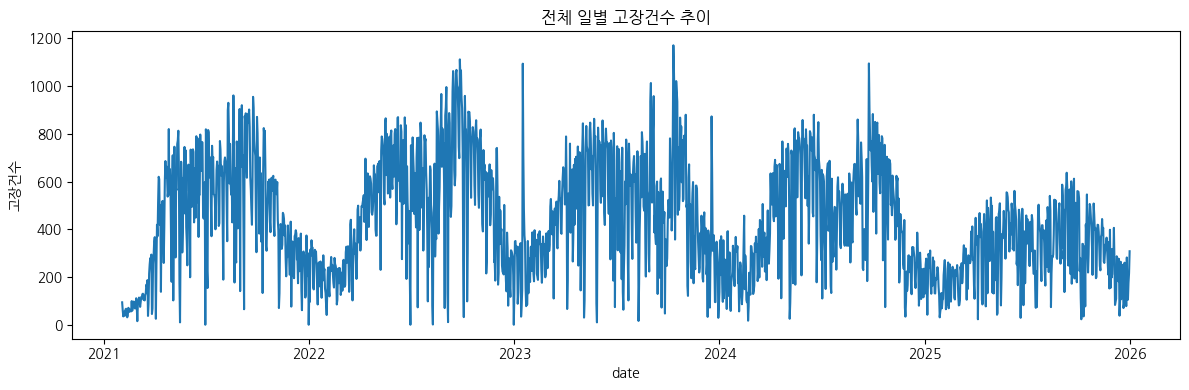

,고장건수
count,1794.00
mean,429.66
std,235.39
min,0.00
25%,245.25
50%,400.50
75%,611.50
max,1171.00


In [6]:
plt.figure(figsize=(12, 4))
plt.plot(global_daily['date'], global_daily['고장건수'], color='#1f77b4')
plt.title('전체 일별 고장건수 추이')
plt.xlabel('date')
plt.ylabel('고장건수')
plt.tight_layout()
plt.show()

display(global_daily['고장건수'].describe().round(2))


### 6. 검증 구간 분리


In [7]:
VALID_DAYS = 60
assert len(global_daily) > VALID_DAYS + 120, '데이터가 너무 짧습니다. VALID_DAYS를 줄이세요.'

train_df = global_daily.iloc[:-VALID_DAYS].copy()
valid_df = global_daily.iloc[-VALID_DAYS:].copy()

print('train:', train_df.shape, train_df['date'].min(), '~', train_df['date'].max())
print('valid:', valid_df.shape, valid_df['date'].min(), '~', valid_df['date'].max())


train: (1734, 2) 2021-02-02 00:00:00 ~ 2025-11-01 00:00:00
valid: (60, 2) 2025-11-02 00:00:00 ~ 2025-12-31 00:00:00


### 7. Prophet 검증


In [8]:
def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def mape(y_true, y_pred):
    y_true = np.array(y_true, dtype=float)
    y_pred = np.array(y_pred, dtype=float)
    mask = y_true != 0
    if mask.sum() == 0:
        return np.nan
    return float(np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100)

prophet_metrics = None
prophet_valid_pred = None
prophet_model = None

prophet_train = train_df.rename(columns={'date': 'ds', '고장건수': 'y'})[['ds', 'y']]

try:
    prophet_model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=False,
        changepoint_prior_scale=0.05,
        seasonality_prior_scale=10.0,
    )
    prophet_model.fit(prophet_train)

    future_valid = prophet_model.make_future_dataframe(periods=VALID_DAYS, freq='D', include_history=False)
    forecast_valid = prophet_model.predict(future_valid)[['ds', 'yhat']].copy()

    prophet_valid_pred = valid_df[['date', '고장건수']].merge(
        forecast_valid.rename(columns={'ds': 'date'}),
        on='date', how='left'
    )
    prophet_valid_pred['yhat'] = prophet_valid_pred['yhat'].clip(lower=0)

    prophet_metrics = {
        'model': 'Prophet',
        'MAE': float(mean_absolute_error(prophet_valid_pred['고장건수'], prophet_valid_pred['yhat'])),
        'RMSE': rmse(prophet_valid_pred['고장건수'], prophet_valid_pred['yhat']),
        'MAPE(%)': mape(prophet_valid_pred['고장건수'], prophet_valid_pred['yhat']),
    }
    print('Prophet metrics:', prophet_metrics)
except Exception as e:
    print('Prophet 학습 실패:', e)


Prophet metrics: {'model': 'Prophet', 'MAE': 146.8134068352445, 'RMSE': 165.17859042780105, 'MAPE(%)': 64.70920508004721}


### 8. XGBoost 검증 (lag/rolling + 재귀예측)


In [9]:
def make_supervised(df):
    z = df.copy()
    z = z.sort_values('date').reset_index(drop=True)

    for lag in [1, 2, 3, 7, 14, 21, 28]:
        z[f'lag_{lag}'] = z['고장건수'].shift(lag)

    z['roll_mean_7'] = z['고장건수'].shift(1).rolling(7).mean()
    z['roll_mean_14'] = z['고장건수'].shift(1).rolling(14).mean()
    z['roll_std_7'] = z['고장건수'].shift(1).rolling(7).std()

    z['dow'] = z['date'].dt.dayofweek
    z['dom'] = z['date'].dt.day
    z['month'] = z['date'].dt.month
    z['weekofyear'] = z['date'].dt.isocalendar().week.astype(int)
    z['t'] = (z['date'] - z['date'].min()).dt.days

    z = z.dropna().reset_index(drop=True)
    return z


def build_feature_row(history_vals, target_date, start_date):
    # history_vals: 과거 실제/예측 값 리스트
    arr = np.array(history_vals, dtype=float)

    def get_lag(k):
        return float(arr[-k]) if len(arr) >= k else float(arr.mean())

    row = {
        'lag_1': get_lag(1),
        'lag_2': get_lag(2),
        'lag_3': get_lag(3),
        'lag_7': get_lag(7),
        'lag_14': get_lag(14),
        'lag_21': get_lag(21),
        'lag_28': get_lag(28),
        'roll_mean_7': float(arr[-7:].mean()) if len(arr) >= 7 else float(arr.mean()),
        'roll_mean_14': float(arr[-14:].mean()) if len(arr) >= 14 else float(arr.mean()),
        'roll_std_7': float(arr[-7:].std()) if len(arr) >= 7 else float(arr.std()),
        'dow': int(target_date.dayofweek),
        'dom': int(target_date.day),
        'month': int(target_date.month),
        'weekofyear': int(target_date.isocalendar().week),
        't': int((target_date - start_date).days),
    }
    return row


sup_train = make_supervised(train_df)
feature_cols = [
    'lag_1', 'lag_2', 'lag_3', 'lag_7', 'lag_14', 'lag_21', 'lag_28',
    'roll_mean_7', 'roll_mean_14', 'roll_std_7',
    'dow', 'dom', 'month', 'weekofyear', 't'
]

xgb_model = XGBRegressor(
    objective='reg:squarederror',
    n_estimators=500,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_alpha=0.0,
    reg_lambda=1.0,
    random_state=42,
)

xgb_model.fit(sup_train[feature_cols], sup_train['고장건수'])

# 검증구간 재귀예측
history_vals = train_df['고장건수'].tolist()
start_date = global_daily['date'].min()
valid_dates = valid_df['date'].tolist()

xgb_valid_hat = []
for d in valid_dates:
    feat = build_feature_row(history_vals, d, start_date)
    x_in = pd.DataFrame([feat])[feature_cols]
    yhat = float(xgb_model.predict(x_in)[0])
    yhat = max(0.0, yhat)
    xgb_valid_hat.append(yhat)
    history_vals.append(yhat)

xgb_valid_pred = valid_df[['date', '고장건수']].copy()
xgb_valid_pred['yhat'] = xgb_valid_hat

xgb_metrics = {
    'model': 'XGBoost',
    'MAE': float(mean_absolute_error(xgb_valid_pred['고장건수'], xgb_valid_pred['yhat'])),
    'RMSE': rmse(xgb_valid_pred['고장건수'], xgb_valid_pred['yhat']),
    'MAPE(%)': mape(xgb_valid_pred['고장건수'], xgb_valid_pred['yhat']),
}

print('XGBoost metrics:', xgb_metrics)


XGBoost metrics: {'model': 'XGBoost', 'MAE': 74.0036844889323, 'RMSE': 94.53293566065737, 'MAPE(%)': 52.791474805575724}


### 9. 모델 비교 및 선택


In [10]:
metric_rows = [xgb_metrics]
if prophet_metrics is not None:
    metric_rows.append(prophet_metrics)

metric_df = pd.DataFrame(metric_rows).sort_values('MAE').reset_index(drop=True)
display(metric_df)

best_model_name = metric_df.iloc[0]['model']
print('선택 모델:', best_model_name)


,model,MAE,RMSE,MAPE(%)
0,XGBoost,74.003684,94.532936,52.791475
1,Prophet,146.813407,165.178590,64.709205


선택 모델: XGBoost


### 10. 전체 학습 + 미래 30일 예측


In [13]:
FORECAST_HORIZON = 30

full_df = global_daily.copy().sort_values('date').reset_index(drop=True)
last_date = full_df['date'].max()
future_dates = pd.date_range(last_date + pd.Timedelta(days=1), periods=FORECAST_HORIZON, freq='D')

# Prophet full fit
prophet_future = None
if prophet_model is not None:
    prophet_full = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=False,
        changepoint_prior_scale=0.05,
        seasonality_prior_scale=10.0,
    )
    prophet_full.fit(full_df.rename(columns={'date': 'ds', '고장건수': 'y'})[['ds', 'y']])
    pf = prophet_full.make_future_dataframe(periods=FORECAST_HORIZON, freq='D', include_history=False)
    prophet_future = prophet_full.predict(pf)[['ds', 'yhat']].rename(columns={'ds': 'date', 'yhat': 'yhat_prophet'})
    prophet_future['yhat_prophet'] = prophet_future['yhat_prophet'].clip(lower=0)
else:
    prophet_full = None

# XGBoost full fit + recursive
sup_full = make_supervised(full_df)
xgb_full = XGBRegressor(
    objective='reg:squarederror',
    n_estimators=500,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_alpha=0.0,
    reg_lambda=1.0,
    random_state=42,
)
xgb_full.fit(sup_full[feature_cols], sup_full['고장건수'])

history_vals = full_df['고장건수'].tolist()
start_date = full_df['date'].min()
xgb_future_vals = []
for d in future_dates:
    feat = build_feature_row(history_vals, d, start_date)
    yhat = float(xgb_full.predict(pd.DataFrame([feat])[feature_cols])[0])
    yhat = max(0.0, yhat)
    xgb_future_vals.append(yhat)
    history_vals.append(yhat)

xgb_future = pd.DataFrame({'date': future_dates, 'yhat_xgb': xgb_future_vals})

# future 결과 결합
future_global = pd.DataFrame({'date': future_dates})
future_global = future_global.merge(xgb_future, on='date', how='left')
if prophet_future is not None:
    future_global = future_global.merge(prophet_future, on='date', how='left')
else:
    future_global['yhat_prophet'] = np.nan

if best_model_name == 'Prophet' and future_global['yhat_prophet'].notna().all():
    future_global['selected_model'] = 'Prophet'
    future_global['yhat_final'] = future_global['yhat_prophet']
else:
    future_global['selected_model'] = 'XGBoost'
    future_global['yhat_final'] = future_global['yhat_xgb']

future_global['yhat_final'] = future_global['yhat_final'].clip(lower=0)

display(future_global.head())
print('미래 총 30일 예측 합계:', int(round(future_global['yhat_final'].sum())))


,date,yhat_xgb,yhat_prophet,selected_model,yhat_final
0,2026-01-01,182.122452,83.855405,XGBoost,182.122452
1,2026-01-02,204.893677,64.203571,XGBoost,204.893677
2,2026-01-03,135.174789,0.000000,XGBoost,135.174789
3,2026-01-04,98.634094,0.000000,XGBoost,98.634094
4,2026-01-05,143.499603,82.405142,XGBoost,143.499603


미래 총 30일 예측 합계: 4831


### 11. 대여소별 예측으로 분배 (UI 지도에 사용)


In [14]:
# 최근 패턴 기반 대여소 비중 계산
end_date = daily['date'].max()
short_start = end_date - pd.Timedelta(days=13)
long_start = end_date - pd.Timedelta(days=55)

short = daily[daily['date'].between(short_start, end_date)]
long = daily[daily['date'].between(long_start, end_date)]

short_share = short.groupby('추정고장대여소ID', as_index=False)['고장건수'].sum().rename(columns={'고장건수': 'short_sum'})
long_share = long.groupby('추정고장대여소ID', as_index=False)['고장건수'].sum().rename(columns={'고장건수': 'long_sum'})

share = station_meta[['추정고장대여소ID']].drop_duplicates().copy()
share = share.merge(short_share, on='추정고장대여소ID', how='left')
share = share.merge(long_share, on='추정고장대여소ID', how='left')
share[['short_sum', 'long_sum']] = share[['short_sum', 'long_sum']].fillna(0.0)

# 최근 비중 + 장기 비중 혼합
if share['short_sum'].sum() > 0:
    share['short_ratio'] = share['short_sum'] / share['short_sum'].sum()
else:
    share['short_ratio'] = 0.0

if share['long_sum'].sum() > 0:
    share['long_ratio'] = share['long_sum'] / share['long_sum'].sum()
else:
    share['long_ratio'] = 0.0

share['ratio'] = 0.7 * share['short_ratio'] + 0.3 * share['long_ratio']
if share['ratio'].sum() == 0:
    share['ratio'] = 1.0 / len(share)
else:
    share['ratio'] = share['ratio'] / share['ratio'].sum()

# 미래 날짜 x 대여소 분배
future_station = future_global[['date', 'yhat_final', 'selected_model']].copy()
future_station['key'] = 1
share['key'] = 1
future_station = future_station.merge(share[['추정고장대여소ID', 'ratio', 'key']], on='key', how='left').drop(columns=['key'])
future_station['pred_fault_count'] = future_station['yhat_final'] * future_station['ratio']

# 메타 결합
future_station = future_station.merge(station_meta, on='추정고장대여소ID', how='left')
future_station['pred_fault_count'] = future_station['pred_fault_count'].clip(lower=0)

# 예측 위험등급 (예측값 분위수 기준)
q90 = future_station['pred_fault_count'].quantile(0.90)
q70 = future_station['pred_fault_count'].quantile(0.70)
future_station['pred_risk'] = 'LOW'
future_station.loc[future_station['pred_fault_count'] >= q70, 'pred_risk'] = 'MID'
future_station.loc[future_station['pred_fault_count'] >= q90, 'pred_risk'] = 'HIGH'

print('future_station shape:', future_station.shape)
display(future_station.head())


future_station shape: (83700, 11)


,date,yhat_final,selected_model,추정고장대여소ID,ratio,pred_fault_count,위도,경도,핫스팟등급,권역,pred_risk
0,2026-01-01,182.122452,XGBoost,00102,0.000286,0.052100,37.555649,126.910629,HIGH,3,LOW
1,2026-01-01,182.122452,XGBoost,00103,0.000154,0.028054,37.554951,126.910835,HIGH,3,LOW
2,2026-01-01,182.122452,XGBoost,00104,0.000680,0.123896,37.550629,126.914986,LOW,3,MID
3,2026-01-01,182.122452,XGBoost,00105,0.000636,0.115881,37.550007,126.914825,LOW,3,MID
4,2026-01-01,182.122452,XGBoost,00106,0.000198,0.036069,37.548645,126.912826,MID,3,LOW


### 12. 저장


In [15]:
# 1) 대여소-일자 예측 (UI 지도/테이블용)
station_out_cols = [
    'date', '추정고장대여소ID', 'pred_fault_count', 'pred_risk',
    '위도', '경도', '핫스팟등급', '권역', 'selected_model'
]
forecast_station_daily = future_station[station_out_cols].copy()

# 2) 전체 일자 예측 (추이 그래프용)
forecast_global_daily = future_global[['date', 'yhat_prophet', 'yhat_xgb', 'yhat_final', 'selected_model']].copy()

# 3) 요약
forecast_summary = (
    forecast_station_daily
    .groupby(['date', 'pred_risk'], as_index=False)
    .agg(
        pred_fault_sum=('pred_fault_count', 'sum'),
        station_cnt=('추정고장대여소ID', 'nunique')
    )
    .sort_values(['date', 'pred_risk'])
    .reset_index(drop=True)
)

station_path = os.path.join(PROCESSED_DIR, 'forecast_station_daily.parquet')
station_csv_path = os.path.join(PROCESSED_DIR, 'forecast_station_daily.csv')
global_path = os.path.join(PROCESSED_DIR, 'forecast_global_daily.parquet')
summary_path = os.path.join(PROCESSED_DIR, 'forecast_summary.parquet')

forecast_station_daily.to_parquet(station_path, index=False)
forecast_station_daily.to_csv(station_csv_path, index=False, encoding='utf-8-sig')
forecast_global_daily.to_parquet(global_path, index=False)
forecast_summary.to_parquet(summary_path, index=False)

# 모델 번들 저장 (XGBoost만 저장)
bundle = {
    'created_at': datetime.datetime.now().isoformat(),
    'best_model': 'XGBoost',
    'valid_days': VALID_DAYS,
    'metrics': metric_df.to_dict(orient='records'),
    'xgb_feature_cols': feature_cols,
    'xgb_model': xgb_full,
}

model_pkl_path = os.path.join(PROCESSED_DIR, 'forecast_model.pkl')
with open(model_pkl_path, 'wb') as f:
    pickle.dump(bundle, f)

print('저장 완료:')
print('-', station_path)
print('-', station_csv_path)
print('-', global_path)
print('-', summary_path)
print('-', model_pkl_path)

저장 완료:
- /content/drive/MyDrive/26-1_BITAmin_TS_project/processed_data/forecast_station_daily.parquet
- /content/drive/MyDrive/26-1_BITAmin_TS_project/processed_data/forecast_station_daily.csv
- /content/drive/MyDrive/26-1_BITAmin_TS_project/processed_data/forecast_global_daily.parquet
- /content/drive/MyDrive/26-1_BITAmin_TS_project/processed_data/forecast_summary.parquet
- /content/drive/MyDrive/26-1_BITAmin_TS_project/processed_data/forecast_model.pkl


### 13. 결과 확인 EDA


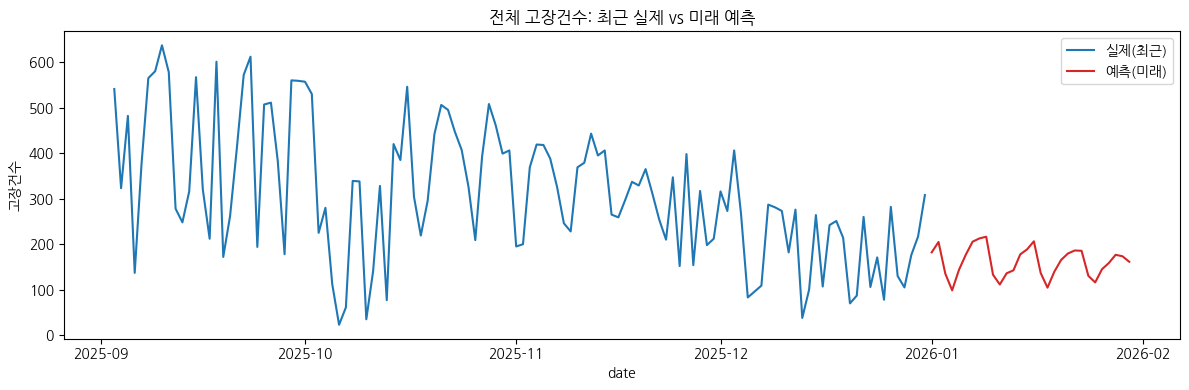

[예측 첫 7일 기준 상위 20개 대여소]


,추정고장대여소ID,pred_fault_count
1701,02728,5.687019
1862,03536,4.226881
1352,02102,3.825345
1860,03533,3.800115
1242,01911,3.624577
766,01151,3.623502
745,01118,3.497349
156,00291,3.472119
109,00236,3.396428
1035,01531,3.179035


In [18]:
# 최근 실제 + 미래 예측
recent_hist = global_daily.tail(120).copy()

plt.figure(figsize=(12, 4))
plt.plot(recent_hist['date'], recent_hist['고장건수'], label='실제(최근)', color='#1f77b4')
plt.plot(forecast_global_daily['date'], forecast_global_daily['yhat_final'], label='예측(미래)', color='#d62728')
plt.title('전체 고장건수: 최근 실제 vs 미래 예측')
plt.xlabel('date')
plt.ylabel('고장건수')
plt.legend()
plt.tight_layout()
plt.show()

# 날짜 타입 맞추기
forecast_station_daily['date'] = pd.to_datetime(forecast_station_daily['date'], errors='coerce')

start_date = forecast_station_daily['date'].min()
end_date = start_date + pd.Timedelta(days=6)

top_pred = (
    forecast_station_daily[
        (forecast_station_daily['date'] >= start_date) &
        (forecast_station_daily['date'] <= end_date)
    ]
    .groupby('추정고장대여소ID', as_index=False)['pred_fault_count']
    .sum()
    .sort_values('pred_fault_count', ascending=False)
    .head(20)
)

print('[예측 첫 7일 기준 상위 20개 대여소]')
display(top_pred)